# Implementation of PCA

In [1]:
#import libararies
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#creating sample dataset
#features=weight, height, age and gender

data={'Height':[170,165,180,175,160,172,168,177,162,158],
     'Weight':[66,59,75,68,55,70,62,74,58,54],
     'Age':[30,25,35,28,22,32,27,33,24,24],
     'Gender':[1,0,1,1,0,1,0,1,0,0]}
#male=1, female=0

df=pd.DataFrame(data)
print(df)

   Height  Weight  Age  Gender
0     170      66   30       1
1     165      59   25       0
2     180      75   35       1
3     175      68   28       1
4     160      55   22       0
5     172      70   32       1
6     168      62   27       0
7     177      74   33       1
8     162      58   24       0
9     158      54   24       0


In [6]:
#Standardize the Data
X=df.drop('Gender', axis=1)
y=df['Gender']
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled

array([[ 0.18419807,  0.26275094,  0.48224282],
       [-0.52425605, -0.70527884, -0.72336423],
       [ 1.60110632,  1.50736066,  1.68784988],
       [ 0.8926522 ,  0.53933088,  0.        ],
       [-1.23271018, -1.25843872, -1.44672847],
       [ 0.46757972,  0.81591082,  0.96448564],
       [-0.09918358, -0.29040893, -0.24112141],
       [ 1.17603385,  1.36907069,  1.20560706],
       [-0.94932853, -0.84356881, -0.96448564],
       [-1.51609183, -1.39672869, -0.96448564]])

In [7]:
#Appling PCA alorithms
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
X_pca

array([[ 0.53556241,  0.21730689],
       [-1.12774594, -0.13585503],
       [ 2.76800382,  0.08109481],
       [ 0.82858116, -0.63337104],
       [-2.27260626, -0.16414736],
       [ 1.29781923,  0.34399793],
       [-0.36475157, -0.09003611],
       [ 2.16656526,  0.01098633],
       [-1.59112734, -0.02531155],
       [-2.24030077,  0.39533512]])

In [9]:
#split the dataset 70% and 30%
X_train,X_test,y_train,y_test=train_test_split(X_pca,y,test_size=0.3,random_state=42)

#apply model
model=LogisticRegression()
model.fit(X_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
#predict the model
y_pred=model.predict(X_test)
y_pred


array([0, 0, 1])

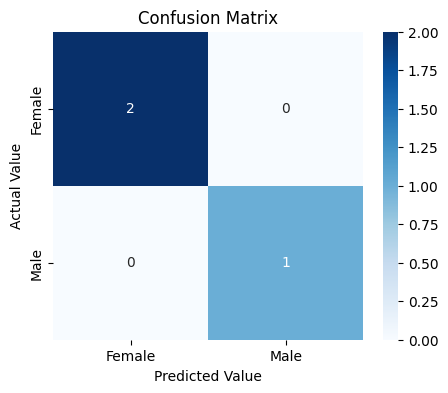

In [15]:
#Evauating with confusion matrix
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues',xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.title('Confusion Matrix')
plt.show()

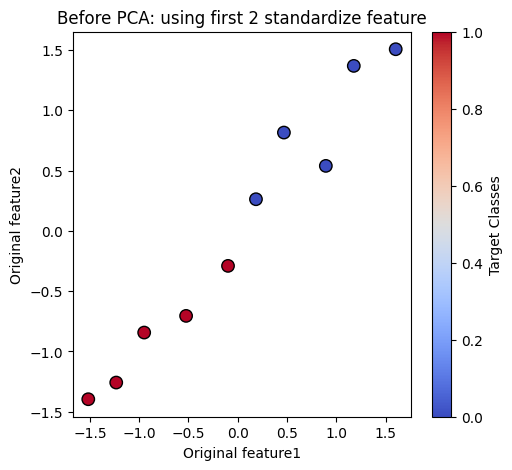

In [20]:
#visulaizing the PCA result
y_num=pd.factorize(y)[0]
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0],X_scaled[:,1], c=y_num, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Original feature1')
plt.ylabel('Original feature2')
plt.title('Before PCA: using first 2 standardize feature')
plt.colorbar(label='Target Classes')
plt.show()


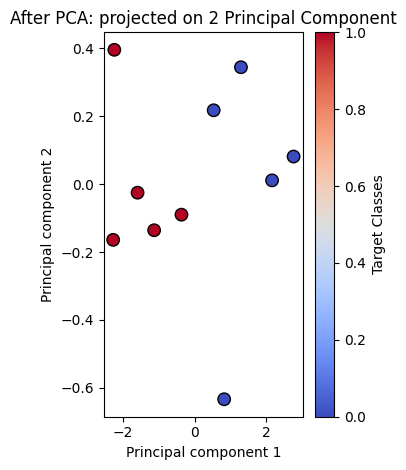

In [21]:
plt.subplot(1,2,2)
plt.scatter(X_pca[:,0],X_pca[:,1], c=y_num, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Principal component 1')
plt.ylabel('Principal component 2')
plt.title('After PCA: projected on 2 Principal Component')
plt.colorbar(label='Target Classes')
plt.tight_layout()
plt.show()